In [1]:
import jax 
import jax.numpy as jnp
import haiku as hk
import optax

from probjax.nn.transformers import Transformer
from probjax.nn.tokenizer import scalarize, ScalarTokenizer
from probjax.nn.helpers import GaussianFourierEmbedding, SinusoidalEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss

import matplotlib.pyplot as plt

from functools import partial

In [2]:
dim =10
def gaussian_simulator(key, n):
    theta = jax.random.normal(key, (n, dim))
    x = theta +  1e-1 * jax.random.normal(key, theta.shape) + 5.
    return jnp.concatenate([theta,x], axis=-1)

data = gaussian_simulator(jax.random.PRNGKey(0), 10000).reshape(-1,dim*2,1)
num_nodes = data.shape[-2]
node_id = jnp.arange(num_nodes)

I0000 00:00:1700591076.974309  287991 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.


In [3]:

def model(t,data, data_id):
    dim = 10
    tokenizer = ScalarTokenizer(dim, len(node_id))
    time_embeder = SinusoidalEmbedding(dim)
    #id_token = hk.Embed(len(node_id), dim//2, w_init = hk.initializers.Orthogonal(scale=0.5))(data_id)
    # id_token = jax.lax.stop_gradient(id_token)
    #val_data = hk.Conv1D(dim//2,1, w_init=jnp.ones, with_bias=False)(data)
    #val_data = hk.nets.MLP([dim, dim//2])(data)
    # val_data = hk.Conv1D(dim//2,1, w_init=jnp.ones, with_bias=False)(data)
    # val_data = jax.lax.stop_gradient(val_data)
    # id_token, val_data = jnp.broadcast_arrays(id_token, val_data)
    # tokens = jnp.concatenate([id_token, val_data], axis=-1)
    
    # Embedding
    tokens = tokenizer(data_id,data)
    time = time_embeder(t[..., None])

    model = Transformer(num_heads=4, num_layers=4, attn_size=dim // 2, widening_factor=20)
    h = model(tokens, context=time)
    out = hk.Linear(1)(h)
    return out

init_fn, model_fn = hk.without_apply_rng(hk.transform(model))
params = init_fn(jax.random.PRNGKey(0), jnp.zeros(data.shape[0],),data, node_id)
out = model_fn(params, jnp.zeros(data.shape[0],),data, node_id)


(10000, 20, 5) (10000, 20, 5)
(10000, 20, 5) (10000, 20, 5)


In [4]:
# VPSDE 
T = 1.
T_min = 1e-6
beta_min = 0.1
beta_max = 10.

# Defines the SDE
def beta(t):
    return beta_min + t * (beta_max - beta_min)

def drift_fn(x, t):
    return -0.5 * (beta(t)) * x

def diffusion_fn(x, t):
    # This migh requrire a square root
    return jnp.sqrt(beta(t)) * jnp.ones_like(x)

# Defines the marginal moments conditioned on x0
def marginal_mean(x0, t):
    phi = jnp.exp(-0.25 * t**2 * (beta_max - beta_min) - 0.5*t * beta_min)
    return phi * x0

def marginal_std(x0, t):
    phi = jnp.exp(-0.5 * t**2 * (beta_max - beta_min) - t * beta_min)
    return jnp.sqrt(1 - 1 * phi)

# Samples from p(x_t|x_o)
def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = marginal_mean(x0, t) + std * noise
    return x_noised

# Score of p(x_t|x_o) for training
log_prob_fn = lambda x, t, x0: jax.scipy.stats.norm.logpdf(x, marginal_mean(x0, t), marginal_std(x0, t)).sum()
score_fn = jax.grad(log_prob_fn)

In [5]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

In [6]:



def loss_fn(params, key, data, node_id):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)
    
    # Generate data and random times
    times = jax.random.uniform(rng_time, (data.shape[0], ), minval=T_min, maxval=1.0)
    batch_xs = data

    # Condition mask -> randomly condition on some data -> Sample more frequently no condition


    # Forward diffusion, do not perturb conditioned data
    batch_noisy_xs = sbd_forward(rng_sample, batch_xs, times.reshape(-1,1,1))

    # Predict score
    print(times.shape, batch_noisy_xs.shape, node_id.shape)
    score_pred = model_fn(params, times, batch_noisy_xs, node_id)
    score_target = score_fn(batch_noisy_xs, times.reshape(-1,1,1), batch_xs)
    
    # Magical weighting function
    lam = 1-jnp.exp(-0.5 * (beta_max - beta_min) * times.reshape(-1,1,1)**2 - beta_min * times.reshape(-1,1,1)) + 1e-6
    
    # Masked loss
    loss = jnp.mean(jnp.sum(lam*(score_pred - score_target) ** 2, axis=-2))
    return loss


In [7]:
# def loss_fn(params, key, data, node_id, mask = None):
#     key_times, key_loss = jax.random.split(key)
#     times = jax.random.uniform(key_times, (data.shape[0],))
#     loss = denoising_score_matching_loss(params, key_loss, times, data, mask, node_id, model_fn = model_fn, mean_fn = sde.marginal_mean, std_fn=sde.marginal_stddev, weight_fn=weight_fn)
#     return loss



@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, key, data, node_id):
    loss, grads = jax.value_and_grad(loss_fn)(params, key, data, node_id)

    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state
    

In [8]:
num_epochs = 1000
batch_size = 800
num_devices = jax.device_count()
batch_size_per_device = batch_size // num_devices
num_steps = data.shape[0] // batch_size + 1

In [9]:
replicated_params = jax.tree_map(lambda x: jnp.array([x] * num_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * num_devices), opt_state)

In [10]:
jax.tree_map(lambda x: x.shape, params)

{'linear': {'b': (1,), 'w': (10, 1)},
 'scalar_tokenizer/conv1_d': {'b': (5,), 'w': (1, 1, 5)},
 'scalar_tokenizer/embed': {'embeddings': (20, 5)},
 'transformer/layer_norm': {'offset': (10,), 'scale': (10,)},
 'transformer/layer_norm_1': {'offset': (10,), 'scale': (10,)},
 'transformer/layer_norm_2': {'offset': (10,), 'scale': (10,)},
 'transformer/layer_norm_3': {'offset': (10,), 'scale': (10,)},
 'transformer/layer_norm_4': {'offset': (10,), 'scale': (10,)},
 'transformer/layer_norm_5': {'offset': (10,), 'scale': (10,)},
 'transformer/layer_norm_6': {'offset': (10,), 'scale': (10,)},
 'transformer/layer_norm_7': {'offset': (10,), 'scale': (10,)},
 'transformer/layer_norm_8': {'offset': (10,), 'scale': (10,)},
 'transformer/linear': {'b': (200,), 'w': (10, 200)},
 'transformer/linear_1': {'b': (10,), 'w': (200, 10)},
 'transformer/linear_10': {'b': (10,), 'w': (200, 10)},
 'transformer/linear_11': {'b': (10,), 'w': (10, 10)},
 'transformer/linear_2': {'b': (10,), 'w': (10, 10)},
 'tr

In [12]:

key = jax.random.PRNGKey(0)
for j in range(num_epochs):
    l = 0
    for i in range(num_steps):
        key, key_batch, key_update = jax.random.split(key, 3)
        data_batch = jax.random.choice(key_batch,data, shape=(num_devices, batch_size_per_device, ), axis=0)
        node_id_batch = jnp.repeat(node_id[None,...], num_devices, axis=0)
        loss, replicated_params, replicated_opt_state = update(replicated_params, replicated_opt_state, jax.random.split(key_update, (num_devices,)), data_batch,node_id_batch)
        l += loss[0] /num_steps
    if (j % 10) == 0:     
        print(l)

(100,) (100, 20, 1) (20,)
20.245438
19.919579
19.824474
19.947765
19.910053
19.87397
19.801369
19.868977
19.695316
19.686079
19.765442
19.904316
19.794127
19.829252
19.785929
19.840557
19.855598
19.942171
19.884472
19.763332
19.772713


KeyboardInterrupt: 

In [15]:
params = jax.tree_map(lambda x: x[0], replicated_params)

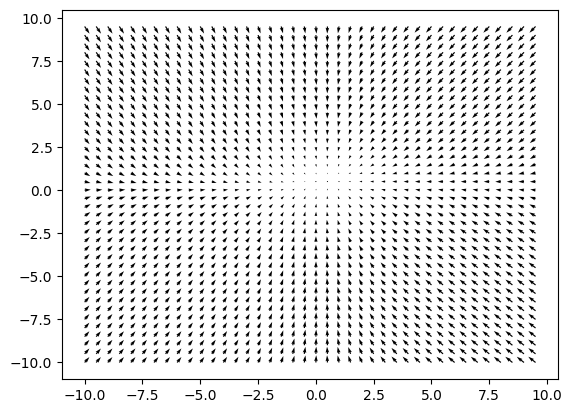

In [16]:
%matplotlib inline
# Check vector field
x, y = jnp.meshgrid(jnp.arange(-10, 10, 0.5), jnp.arange(-10, 10, 0.5))
pos = jnp.dstack((x, y)).reshape(-1, 2, 1)
vs = model_fn(params, jnp.ones((pos.shape[0],)) * 1., pos, jnp.array([0,1]))

plt.quiver(pos[:, 0], pos[:, 1], vs[:, 0], vs[:, 1])

In [17]:

def score_fn(t, x):
    score = model_fn(params, jnp.atleast_1d(t), x.reshape(-1, num_nodes, 1), node_id)
    return score.reshape(x.shape)

def drift_backwards(t, x):
    score = score_fn(t, x)
    drift = drift_fn(x, t)  -  diffusion_fn(x, t)**2 * score
    return drift.reshape(dim*2)

def diffusion_backwards(t, x):
    diffusion = diffusion_fn(x, t)
    return diffusion.reshape(dim*2)

# t = jnp.linspace(0,1-T_min,200)
# p_T = Independent(Normal(sde.marginal_mean(jnp.ones(1)), sde.marginal_stddev(jnp.ones(1))), 2)
# target_sde = BaseSDE(drift_backwards, diffusion_backwards, p_T)

In [18]:
from probjax.utils.sdeint import sdeint


def sample_fn(key, shape, node_ids=node_id, time_steps=500, condition_mask=jnp.zeros((4,), dtype=int), condition_value=jnp.zeros((4,)), mask=None):
    #condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jax.random.split(key, 2)
    # Sample from noise distribution at time 1
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros((1,)), 1.) + marginal_mean(jnp.zeros((1,)), 1.)
    # If conditioned on certain variables, replace with conditioned value
    #x_T = x_T * (1-condition_mask) + condition_value * condition_mask
    # Sove backward sde
    print(x_T.shape)
    keys = jax.random.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backwards(t, x), lambda t, x: diffusion_backwards(t, x), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys


In [19]:
samples = sample_fn(jax.random.PRNGKey(1), (100,), time_steps=500)

(100, 20)


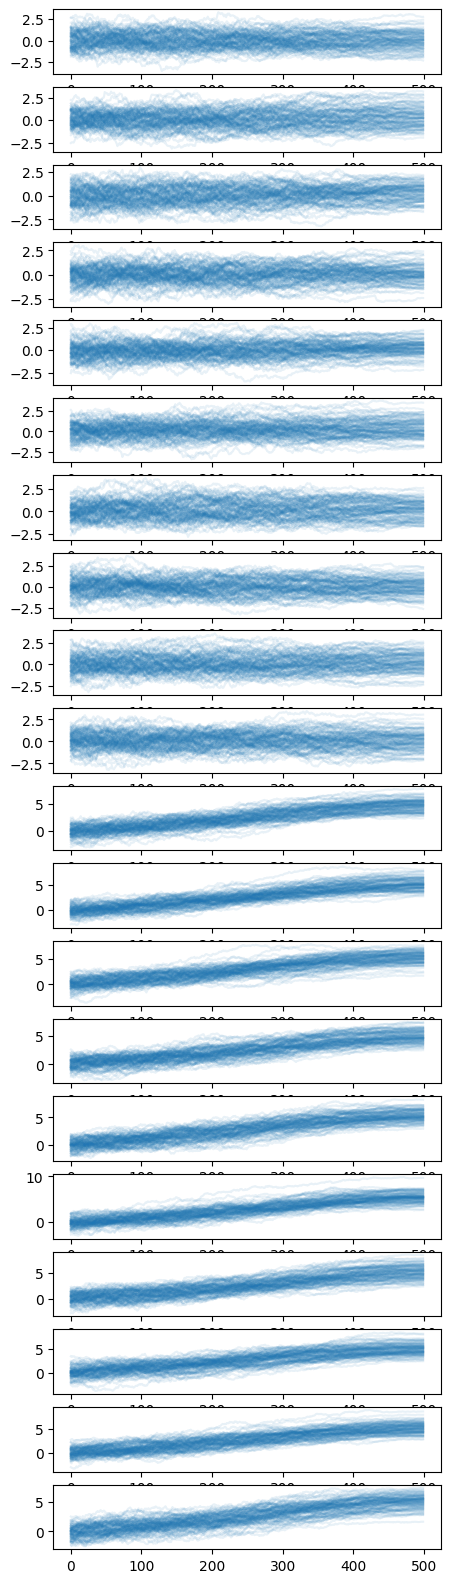

In [20]:

#forward_samples = target_sde.sample(jax.random.PRNGKey(0), t, sample_shape=(100,))

fig, axes = plt.subplots(dim*2,1, figsize=(5, dim*2))
for i in range(dim*2):
    _ = axes[i].plot(samples[...,i].T, color="C0", alpha=0.1)


ValueError: Incompatible shapes for broadcasting: shapes=[(1000, 1, 4), (2,)]